# Week 5: Model Comparison

**Project:** Automated Casting Defect Detection Using Deep Learning and Computer Vision

## Objective
Week 5 compares multiple candidate models under the same preprocessing, split and validation metrics. The aim is to justify the final model choice rather than selecting a model without evidence.

## Team Contributions
| Member | Name | Role | Week 5 Contribution |
|---|---|---|---|
| 1 | Sandeep Bommagoni | Data & EDA Lead | Verified clean split and class weights |
| 2 | Likith Kumar Devulapalli | Architecture / Xception Lead | Built reusable transfer-learning model builder |
| 3 | Raghava Krishna Battu | Model Comparison Lead | Trained MobileNetV2, EfficientNetB0, DenseNet121 and Xception |
| 4 | Navatej Patel Cheerneni | Evaluation & XAI Lead | Created model ranking, metrics and comparison plots |
| 5 | Tharun Chinnachinnaiahgari | GitHub / Deployment Lead | Saved outputs, summaries, trackers and GitHub evidence |

In [1]:

import os, json, random, time
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score
SEED=123
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.17.0


## 1. Configuration and Clean Split
**Contributor:** Sandeep Bommagoni

This cell prepares the dataset and creates a shared split so all models are compared fairly.

In [2]:

DATASET_ROOT = Path('/kaggle/input/real-life-industrial-dataset-of-casting-product')
IMAGE_SIZE=(224,224); BATCH_SIZE=24
LABEL_TO_ID={'ok_front':0,'def_front':1}; ID_TO_LABEL={0:'ok_front',1:'def_front'}
OUTPUT_DIR=Path('/kaggle/working/week5_model_comparison')
MODEL_DIR=OUTPUT_DIR/'models'; PLOT_DIR=OUTPUT_DIR/'plots'; REPORT_DIR=OUTPUT_DIR/'reports'
for d in [MODEL_DIR,PLOT_DIR,REPORT_DIR]: d.mkdir(parents=True, exist_ok=True)
SUPPORTED={'.jpg','.jpeg','.png','.bmp'}

def discover_source(root):
    pairs=[]
    for d in root.rglob('def_front'):
        if (d.parent/'ok_front').is_dir(): pairs.append(d.parent)
    if not pairs: raise FileNotFoundError('No def_front/ok_front folder pair found')
    raw=[p for p in sorted(set(pairs)) if '512' in str(p).lower()]
    return raw[0] if raw else sorted(set(pairs))[0]

selected_source=discover_source(DATASET_ROOT)
print('Selected source:', selected_source)
rows=[]
for label_name,label_id in LABEL_TO_ID.items():
    for path in sorted((selected_source/label_name).iterdir()):
        if path.is_file() and path.suffix.lower() in SUPPORTED:
            img=cv2.imread(str(path))
            rows.append({'path':str(path),'filename':path.name,'label_name':label_name,'label':label_id,'readable':img is not None})
manifest=pd.DataFrame(rows); manifest=manifest[manifest.readable].reset_index(drop=True)
train_df,temp_df=train_test_split(manifest,train_size=.70,stratify=manifest.label,random_state=SEED)
val_df,test_df=train_test_split(temp_df,train_size=.50,stratify=temp_df.label,random_state=SEED)
train_df=train_df.reset_index(drop=True); val_df=val_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
split_manifest=pd.concat([train_df.assign(split='train'),val_df.assign(split='validation'),test_df.assign(split='test')],ignore_index=True)
split_counts=split_manifest.groupby(['split','label_name']).size().reset_index(name='images')
display(split_counts)
manifest.to_csv(REPORT_DIR/'week5_clean_image_manifest.csv',index=False)
split_manifest.to_csv(REPORT_DIR/'week5_train_validation_test_manifest.csv',index=False)
split_counts.to_csv(REPORT_DIR/'week5_split_counts.csv',index=False)
weights=compute_class_weight('balanced',classes=np.array([0,1]),y=train_df.label.to_numpy())
CLASS_WEIGHTS={0:float(weights[0]),1:float(weights[1])}
with open(REPORT_DIR/'week5_class_weights.json','w') as f: json.dump(CLASS_WEIGHTS,f,indent=4)
print('Class weights:',CLASS_WEIGHTS)


Selected source: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512


,split,label_name,images
0,test,def_front,118
1,test,ok_front,78
2,train,def_front,546
3,train,ok_front,363
4,validation,def_front,117
5,validation,ok_front,78


Class weights: {0: 1.2520661157024793, 1: 0.8324175824175825}


## 2. TensorFlow Pipeline
**Contributor:** Likith Kumar Devulapalli

In [4]:

AUTOTUNE=tf.data.AUTOTUNE

def decode_resize(path,label):
    img=tf.io.decode_image(tf.io.read_file(path),channels=3,expand_animations=False)
    img.set_shape([None,None,3]); img=tf.image.resize(img,IMAGE_SIZE,antialias=True)
    return tf.cast(img,tf.float32), tf.cast(label,tf.float32)

def make_ds(df,training=False):
    ds=tf.data.Dataset.from_tensor_slices((df.path.astype(str).to_numpy(),df.label.astype(np.float32).to_numpy()))
    if training: ds=ds.shuffle(len(df),seed=SEED,reshuffle_each_iteration=True)
    return ds.map(decode_resize,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
train_ds=make_ds(train_df,True); val_ds=make_ds(val_df,False); test_ds=make_ds(test_df,False)
for x,y in train_ds.take(1): print(x.shape,y.shape)


(24, 224, 224, 3) (24,)


## 3. Build Comparison Models
**Contributor:** Likith Kumar Devulapalli

A common classification head is used for all transfer-learning backbones.

In [5]:

def augmentation():
    return keras.Sequential([layers.RandomFlip('horizontal'),layers.RandomRotation(.04),layers.RandomZoom(.08),layers.RandomContrast(.10)],name='augmentation')
CONFIGS={
 'MobileNetV2':(keras.applications.MobileNetV2,keras.applications.mobilenet_v2.preprocess_input),
 'EfficientNetB0':(keras.applications.EfficientNetB0,keras.applications.efficientnet.preprocess_input),
 'DenseNet121':(keras.applications.DenseNet121,keras.applications.densenet.preprocess_input),
 'Xception':(keras.applications.Xception,keras.applications.xception.preprocess_input),
}

def build_model(name):
    cls,pre=CONFIGS[name]
    inp=keras.Input(shape=IMAGE_SIZE+(3,),name='image')
    x=augmentation()(inp); x=pre(x)
    try:
        base=cls(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE+(3,),pooling='avg',name=name.lower())
        print('Loaded ImageNet weights:',name)
    except Exception as e:
        print('ImageNet unavailable, using random weights for',name,e)
        base=cls(include_top=False,weights=None,input_shape=IMAGE_SIZE+(3,),pooling='avg',name=name.lower())
    base.trainable=False
    x=base(x,training=False); x=layers.BatchNormalization()(x); x=layers.Dense(256,activation='relu')(x); x=layers.Dropout(.35)(x)
    out=layers.Dense(1,activation='sigmoid',name='probability_defective')(x)
    model=keras.Model(inp,out,name='Week5_'+name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',metrics=['accuracy',keras.metrics.Precision(name='defect_precision'),keras.metrics.Recall(name='defect_recall'),keras.metrics.AUC(name='roc_auc'),keras.metrics.AUC(name='pr_auc',curve='PR')])
    return model


## 4. Train Models
**Contributor:** Raghava Krishna Battu

In [6]:

def callbacks(name):
    s=name.lower()
    return [keras.callbacks.ModelCheckpoint(MODEL_DIR/f'week5_{s}_best.keras',monitor='val_pr_auc',mode='max',save_best_only=True),keras.callbacks.EarlyStopping(monitor='val_pr_auc',mode='max',patience=3,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.3,patience=2,min_lr=1e-7),keras.callbacks.CSVLogger(REPORT_DIR/f'week5_{s}_training_log.csv')]
models_to_train=['MobileNetV2','EfficientNetB0','DenseNet121','Xception']
trained={}; histories={}; train_minutes={}
EPOCHS=8
for name in models_to_train:
    print('\nTraining',name)
    m=build_model(name); start=time.time()
    h=m.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,class_weight=CLASS_WEIGHTS,callbacks=callbacks(name),verbose=1)
    train_minutes[name]=(time.time()-start)/60; trained[name]=m; histories[name]=pd.DataFrame(h.history)
    histories[name].to_csv(REPORT_DIR/f'week5_{name.lower()}_history.csv',index=False)
    m.save(MODEL_DIR/f'week5_{name.lower()}_model.keras')



Training MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Loaded ImageNet weights: MobileNetV2
Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.8112 - defect_precision: 0.8671 - defect_recall: 0.8202 - loss: 0.4481 - pr_auc: 0.9265 - roc_auc: 0.8842 - val_accuracy: 0.8615 - val_defect_precision: 0.8214 - val_defect_recall: 0.9829 - val_loss: 0.3001 - val_pr_auc: 0.9862 - val_roc_auc: 0.9775 - learning_rate: 0.0010
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9691 - defect_precision: 0.9908 - defect_recall: 0.9577 - loss: 0.0963 - pr_auc: 0.9965 - roc_auc: 0.9941 - val_accuracy: 0.9641 - val_defect_precision: 0.9583 - val_defect_recall: 0.9829 - val_loss: 0.1765 - val_pr_auc: 0.9937 - val_roc_auc: 0.9899 - learning_rate: 0.0010
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9757 - defect_precision: 0.9882 - defect_recall: 0.9710 - loss: 0.0727 - pr_auc: 0.9978 - roc_auc: 0.9966 - val_accuracy: 0.9487 - val_defect_precisio

## 5. Evaluate and Rank Models
**Contributor:** Navatej Patel Cheerneni

,model,accuracy,defect_precision,defect_recall,f1_defect,roc_auc,pr_auc,training_minutes
0,DenseNet121,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.002970
1,Xception,0.994872,1.000000,0.991453,0.995708,0.999343,0.999583,0.729977
2,MobileNetV2,0.979487,1.000000,0.965812,0.982609,0.998795,0.999218,0.584262
3,EfficientNetB0,0.958974,0.943089,0.991453,0.966667,0.997370,0.998327,0.605568


Selected model: DenseNet121


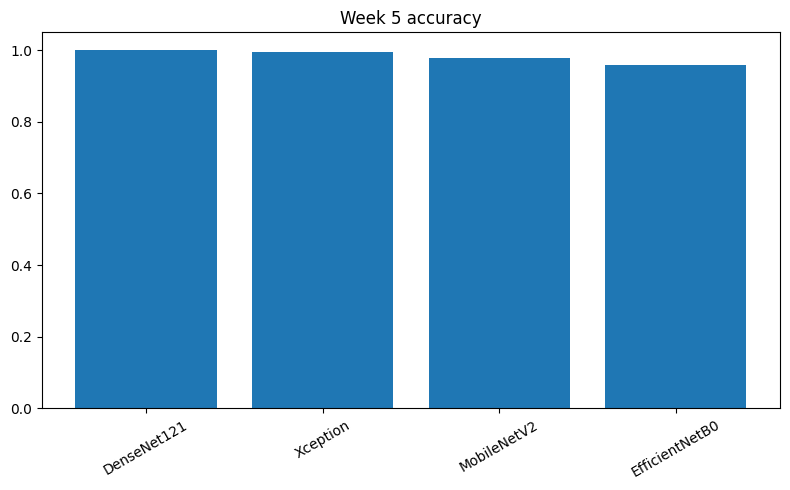

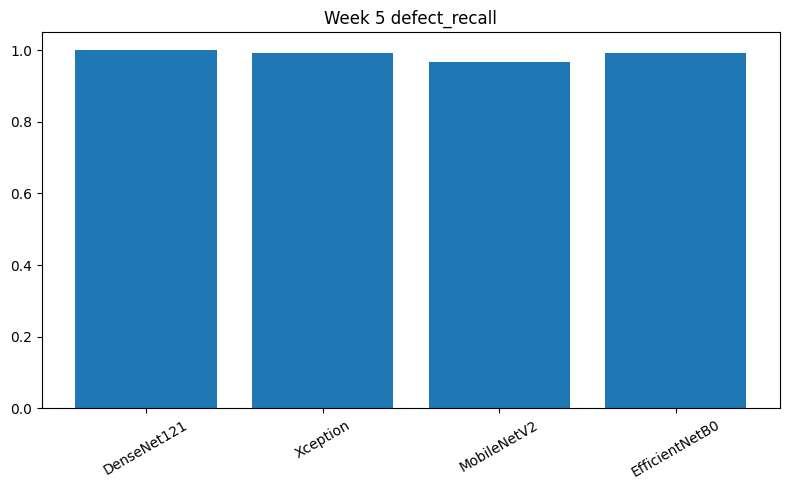

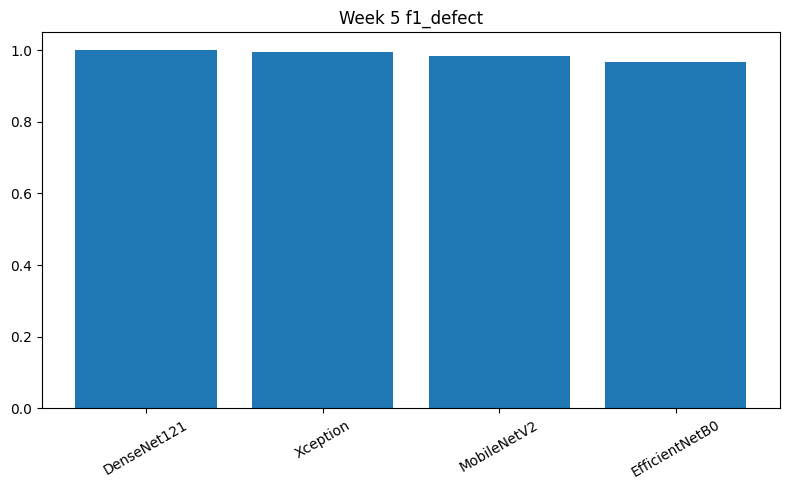

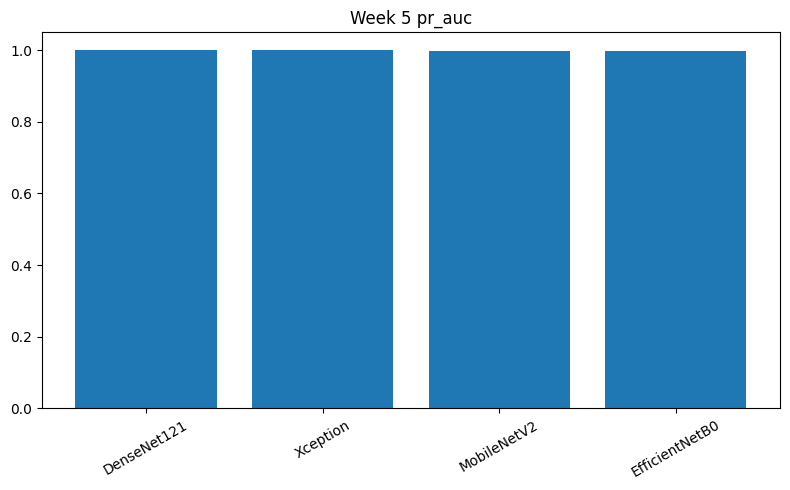

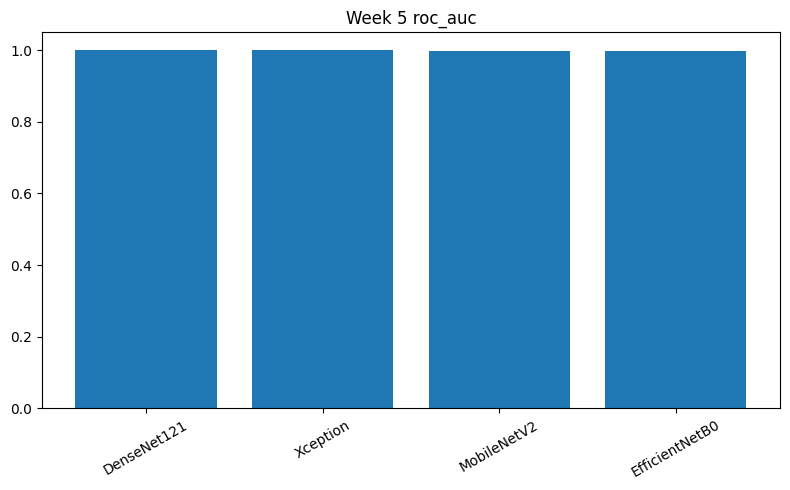

In [7]:

def labels(ds): return np.concatenate([y.numpy().reshape(-1) for _,y in ds]).astype(int)
def probs(model,ds): return model.predict(ds,verbose=0).reshape(-1)
y_val=labels(val_ds); rows=[]
for name,m in trained.items():
    p=probs(m,val_ds); pred=(p>=.5).astype(int)
    rows.append({'model':name,'accuracy':float(accuracy_score(y_val,pred)),'defect_precision':float(precision_score(y_val,pred,pos_label=1,zero_division=0)),'defect_recall':float(recall_score(y_val,pred,pos_label=1,zero_division=0)),'f1_defect':float(f1_score(y_val,pred,pos_label=1,zero_division=0)),'roc_auc':float(roc_auc_score(y_val,p)),'pr_auc':float(average_precision_score(y_val,p)),'training_minutes':float(train_minutes[name])})
comparison_df=pd.DataFrame(rows).sort_values(['pr_auc','defect_recall','f1_defect'],ascending=False).reset_index(drop=True)
display(comparison_df)
comparison_df.to_csv(REPORT_DIR/'week5_model_comparison_table.csv',index=False)
best_model=comparison_df.loc[0,'model']
with open(REPORT_DIR/'week5_selected_model.json','w') as f: json.dump({'selected_model':best_model,'selection_rule':'Highest validation PR-AUC, then defect recall, then F1'},f,indent=4)
print('Selected model:',best_model)
for metric in ['accuracy','defect_recall','f1_defect','pr_auc','roc_auc']:
    fig,ax=plt.subplots(figsize=(8,5)); ax.bar(comparison_df.model,comparison_df[metric]); ax.set_ylim(0,1.05); ax.set_title('Week 5 '+metric); ax.tick_params(axis='x',rotation=30); plt.tight_layout(); plt.savefig(PLOT_DIR/f'week5_model_comparison_{metric}.png',dpi=160); plt.show()


## 6. Week 5 Findings
**Contributors:** All team members

Week 5 produced validation-based evidence for model selection. The best model from this comparison will be fine-tuned in Week 6.

In [8]:
import os
import zipfile
from pathlib import Path

# Folder to compress
source_folder = Path("/kaggle/working/week5_model_comparison")

# ZIP file location
zip_path = Path("/kaggle/working/week5_model_comparison.zip")

if not source_folder.exists():
    raise FileNotFoundError(f"Folder not found: {source_folder}")

# Remove an incomplete ZIP from a previous attempt
if zip_path.exists():
    zip_path.unlink()

files = [p for p in source_folder.rglob("*") if p.is_file()]
print(f"Found {len(files):,} files.")
print("Creating ZIP file...")

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as zip_file:

    for index, file_path in enumerate(files, start=1):
        # Preserve the main folder name inside the ZIP
        archive_name = file_path.relative_to(source_folder.parent)
        zip_file.write(file_path, archive_name)

        if index % 100 == 0 or index == len(files):
            print(f"Compressed {index:,}/{len(files):,} files", end="\r")

zip_size_gb = zip_path.stat().st_size / (1024 ** 3)

print("\n\nZIP creation completed successfully.")
print(f"ZIP location: {zip_path}")
print(f"ZIP size: {zip_size_gb:.2f} GB")

Found 27 files.
Creating ZIP file...
Compressed 27/27 files

ZIP creation completed successfully.
ZIP location: /kaggle/working/week5_model_comparison.zip
ZIP size: 0.27 GB
